# Goal: Set up paths, load libraries once, and define where outputs (tables/figures) will be saved. This notebook will produce the final analysis needed for the report:

- Storm typology (clustering)

- Model vs observed comparison

- Predicting erosion months from storm conditions

In [1]:
# ============================================================
# storm_typology_and_erosion_analysis.ipynb
# Final notebook: storm typology + model validation + erosion link
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# (Optional) models for Objective 3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# -----------------------------
# Project directories (EDIT if needed)
# -----------------------------
PROJECT_DIR = Path(r"C:\Users\anura\Downloads\DATA601-PROJECT")   
RESULTS_DIR = PROJECT_DIR / "results"
TABLE_DIR   = RESULTS_DIR / "tables"
FIG_DIR     = RESULTS_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("TABLE_DIR  :", TABLE_DIR)
print("FIG_DIR    :", FIG_DIR)


PROJECT_DIR: C:\Users\anura\Downloads\DATA601-PROJECT
TABLE_DIR  : C:\Users\anura\Downloads\DATA601-PROJECT\results\tables
FIG_DIR    : C:\Users\anura\Downloads\DATA601-PROJECT\results\figures


## 1. Load the Master dataset
### What this dataset is:
"storm_shoreline_merged_monthly.csv" is your master monthly table linking:

- shoreline change (monthly)

- buoy storm metrics (monthly)

- hindcast storm metrics (monthly)

- an erosion flag (erosion_month)

This is the dataset we use to answer all 3 objectives without mixing transect-level raw series.

In [2]:
# -----------------------------
# Load master dataset
# -----------------------------
df = pd.read_csv(TABLE_DIR / "storm_shoreline_merged_monthly.csv")

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()


Rows: 314
Columns: ['month', 'mean_shoreline_change', 'ecan_storm_hours', 'ecan_max_Hs', 'ecan_mean_Hs', 'ecan_mean_dir', 'model_storm_hours', 'model_max_Hs', 'model_mean_Hs', 'model_mean_dir', 'erosion_month']


,month,mean_shoreline_change,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,ecan_mean_dir,model_storm_hours,model_max_Hs,model_mean_Hs,model_mean_dir,erosion_month
0,1999-07-01,NaN,10.0,3.22,2.694000,150.844000,20.0,6.1611,4.835027,148.519700,False
1,1999-08-01,2.105517,7.0,3.60,3.117143,177.682857,2.0,4.4776,4.375580,195.086000,False
2,1999-09-01,3.266016,2.0,3.62,3.160000,161.105000,7.0,4.5849,4.377566,197.312429,False
3,1999-10-01,3.780714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1999-11-01,1.193659,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. Fix dtypes (month column) + quick sanity checks
### Why this matters:
The month column needs to be a datetime so we can:

- sort time properly

- filter ranges

- create plots
We also do a quick check for missing values.

In [3]:
# -----------------------------
# Parse month column (your file uses strings like "01-07-1999")
# -----------------------------
df["month"] = pd.to_datetime(df["month"], dayfirst=True, errors="coerce")

# Sort by time
df = df.sort_values("month").reset_index(drop=True)

# Quick checks
print("Month range:", df["month"].min(), "to", df["month"].max())
print("\nMissing values per column (top 15):")
display(df.isna().sum().sort_values(ascending=False).head(15))

# Check erosion flag
if "erosion_month" in df.columns:
    print("\nErosion flag counts:")
    display(df["erosion_month"].value_counts(dropna=False))


Month range: 1999-01-07 00:00:00 to 2025-01-11 00:00:00

Missing values per column (top 15):


model_storm_hours        131
model_max_Hs             131
model_mean_Hs            131
model_mean_dir           131
ecan_storm_hours          14
ecan_max_Hs               14
ecan_mean_Hs              14
ecan_mean_dir             14
mean_shoreline_change      1
month                      0
erosion_month              0
dtype: int64


Erosion flag counts:


erosion_month
False    163
True     151
Name: count, dtype: int64

## 3. Basic descriptive summary for the report
### What we produce here:
A clean descriptive table you can drop in the report:
- mean, std, min, max for key variables.
  
This helps justify thresholds and show what “storm months” look like.

In [4]:
key_cols = [
    "mean_shoreline_change",
    "ecan_storm_hours", "ecan_max_Hs", "ecan_mean_Hs", "ecan_mean_dir",
    "model_storm_hours", "model_max_Hs", "model_mean_Hs", "model_mean_dir",
    "erosion_month"
]

available = [c for c in key_cols if c in df.columns]
summary = df[available].describe(include="all").T

display(summary)

# Export for report
out_path = TABLE_DIR / "table_master_descriptives.csv"
summary.to_csv(out_path)
print("Saved:", out_path)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mean_shoreline_change,313.0,NaN,NaN,NaN,0.064943,1.399675,-6.091395,-0.711074,0.063736,0.868104,5.756565
ecan_storm_hours,300.0,NaN,NaN,NaN,23.92,13.43286,1.0,14.0,22.0,31.25,75.0
ecan_max_Hs,300.0,NaN,NaN,NaN,2.941,0.277491,2.56,2.79,2.87,3.0125,5.47
ecan_mean_Hs,300.0,NaN,NaN,NaN,2.626515,0.080804,2.549545,2.5899,2.608745,2.631277,3.167692
ecan_mean_dir,300.0,NaN,NaN,NaN,151.022468,30.796933,62.14,130.490119,153.52826,174.905469,234.9
model_storm_hours,183.0,NaN,NaN,NaN,11.071038,9.568744,1.0,4.0,8.0,15.0,54.0
model_max_Hs,183.0,NaN,NaN,NaN,5.370623,1.032347,4.02764,4.50615,5.13255,6.038125,8.71274
model_mean_Hs,183.0,NaN,NaN,NaN,4.665122,0.443203,4.02764,4.30101,4.605518,4.898839,6.450097
model_mean_dir,183.0,NaN,NaN,NaN,182.803544,34.814786,45.7828,180.586007,197.395909,202.047904,224.124
erosion_month,314,2,False,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\table_master_descriptives.csv


## 4. Build clustering dataset (buoy-based)
### Why we cluster:
We want a storm typology based on wave characteristics.
We cluster monthly storm conditions using buoy metrics:

- storm duration proxy (ecan_storm_hours)

- storm intensity (ecan_max_Hs, ecan_mean_Hs)

- storm direction (ecan_mean_dir)

Note about direction: ecan_mean_dir is circular (0° = 360°).
For a robust approach you should transform direction into sine/cosine. We do that here.

In [5]:
# -----------------------------
# Select buoy storm features (monthly)
# -----------------------------
storm_feat = ["ecan_storm_hours", "ecan_max_Hs", "ecan_mean_Hs", "ecan_mean_dir"]
missing = [c for c in storm_feat if c not in df.columns]
if missing:
    raise ValueError(f"Missing required buoy storm columns: {missing}")

clust = df[["month", "mean_shoreline_change", "erosion_month"] + storm_feat].copy()

# -----------------------------
# Convert direction to circular components
# -----------------------------
dir_rad = np.deg2rad(clust["ecan_mean_dir"])
clust["dir_sin"] = np.sin(dir_rad)
clust["dir_cos"] = np.cos(dir_rad)

# Use transformed direction instead of raw degrees
X_cols = ["ecan_storm_hours", "ecan_max_Hs", "ecan_mean_Hs", "dir_sin", "dir_cos"]

# Keep only rows where we have at least something (we will impute)
X = clust[X_cols].copy()

print("Clustering feature columns:", X_cols)
display(X.head())


Clustering feature columns: ['ecan_storm_hours', 'ecan_max_Hs', 'ecan_mean_Hs', 'dir_sin', 'dir_cos']


,ecan_storm_hours,ecan_max_Hs,ecan_mean_Hs,dir_sin,dir_cos
0,10.0,3.22,2.694000,0.487189,-0.873296
1,7.0,3.60,3.117143,0.040431,-0.999182
2,2.0,3.62,3.160000,0.323835,-0.946114
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


## 5. Impute + Scale features
### Why Impute and Scale:
Clustering needs a complete numeric matrix.

- We impute missing values (median)

- We standardise features so Hs doesn’t dominate storm hours just because units differ

In [6]:
# -----------------------------
# Impute missing values (median) + standardise
# -----------------------------
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_std = scaler.fit_transform(X_imp)

print("Shape after impute/scale:", X_std.shape)


Shape after impute/scale: (314, 5)


## 6. Choose number of clusters (k) safely


Samples available for clustering: 314


C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

Silhouette scores:


2     0.289415
3     0.337416
4     0.303948
5     0.274566
6     0.286989
7     0.272425
8     0.280103
9     0.283590
10    0.304602
dtype: float64

Inertias:


2     1173.155019
3      858.819358
4      691.168263
5      593.109291
6      503.206933
7      452.741176
8      404.056956
9      363.695814
10     323.812390
dtype: float64

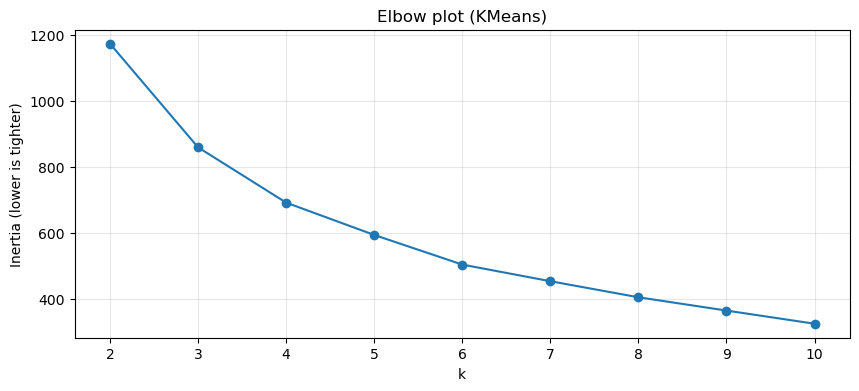

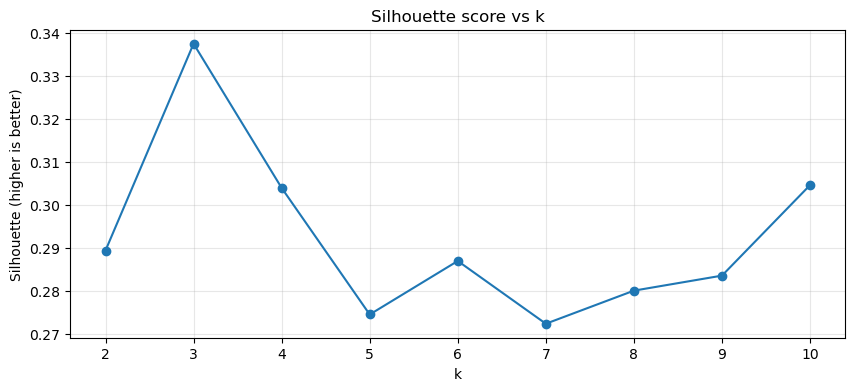

In [7]:
n = X_std.shape[0]
print("Samples available for clustering:", n)

# Safe k range
k_min = 2
k_max = min(10, n-1)   # silhouette requires k <= n-1

if k_max < 2:
    raise ValueError("Not enough rows for clustering. Need at least 3 valid samples.")

sil_scores = {}
inertias = {}

for k in range(k_min, k_max + 1):
    km = KMeans(n_clusters=k, n_init=20, random_state=0)
    labels = km.fit_predict(X_std)

    inertias[k] = km.inertia_
    sil_scores[k] = silhouette_score(X_std, labels)

print("Silhouette scores:")
display(pd.Series(sil_scores).sort_index())

print("Inertias:")
display(pd.Series(inertias).sort_index())

# Plot elbow + silhouette
plt.figure(figsize=(10,4))
plt.plot(list(inertias.keys()), list(inertias.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Inertia (lower is tighter)")
plt.title("Elbow plot (KMeans)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette (higher is better)")
plt.title("Silhouette score vs k")
plt.grid(True, alpha=0.3)
plt.show()


## 7. Fit final clustering model + label storm types
Pick k based on:

- best silhouette

- interpretability (usually 3–5 types)

We assign the label as storm_type for each month and export a table.

In [8]:
# -----------------------------
# Choose k (automatic suggestion = best silhouette)
# -----------------------------
best_k = max(sil_scores, key=sil_scores.get)
print("Suggested best k by silhouette:", best_k)

# You can override if needed:
K_FINAL = best_k

km_final = KMeans(n_clusters=K_FINAL, n_init=50, random_state=0)
clust["storm_type"] = km_final.fit_predict(X_std)

# Merge back into main df
df = df.merge(clust[["month", "storm_type"]], on="month", how="left")

display(df[["month","storm_type"]].head(12))

# Export labelled dataset
out_path = TABLE_DIR / "master_with_storm_types.csv"
df.to_csv(out_path, index=False)
print("Saved:", out_path)


Suggested best k by silhouette: 3


C:\Users\anura\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,month,storm_type
0,1999-01-07,1
1,1999-01-08,2
2,1999-01-09,2
3,1999-01-10,1
4,1999-01-11,1
5,1999-01-12,1
6,2000-01-01,1
7,2000-01-02,1
8,2000-01-03,1
9,2000-01-04,1


Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\master_with_storm_types.csv


## 8. Storm type summary + shoreline response by type
This directly answers Objective 1:

- What are typical wave properties for each storm type?

- Which types have more negative shoreline change (erosion)?

We produce:

- summary table per storm type

- boxplot of shoreline change by type

ecan_storm_hours                              ecan_max_Hs  \
                      count       mean median        std       count   
storm_type                                                             
0                        96  22.635417   22.0  12.381752          96   
1                       184  25.951087   23.5  13.717397         184   
2                        20  11.400000    9.0   6.885530          20   

                                      ecan_mean_Hs                      \
                mean median       std        count      mean    median   
storm_type                                                               
0           2.883125  2.845  0.183098           96  2.610475  2.601962   
1           2.900652  2.860  0.170789          184  2.609857  2.608087   
2           3.590000  3.420  0.535842           20  2.856758  2.824931   

                     ecan_mean_dir                                     \
                 std         count        mean      median        std   
storm_type                                                              
0           0.040395            96  115.269821  117.729405  18.272219   
1           0.029012           184  167.325899  165.825758  18.354051   
2           0.163387            20  172.643613  179.435317  22.067159   

           mean_shoreline_change                                
                           count      mean    median       std  
storm_type                                                      
0                             96  0.187096  0.216880  1.229467  
1                            197 -0.028980 -0.066991  1.333797  
2                             20  0.403746  0.493684  2.443929

Saved: C:\Users\anura\Downloads\DATA601-PROJECT\results\tables\table_storm_type_summary.csv


<Figure size 1000x500 with 0 Axes>

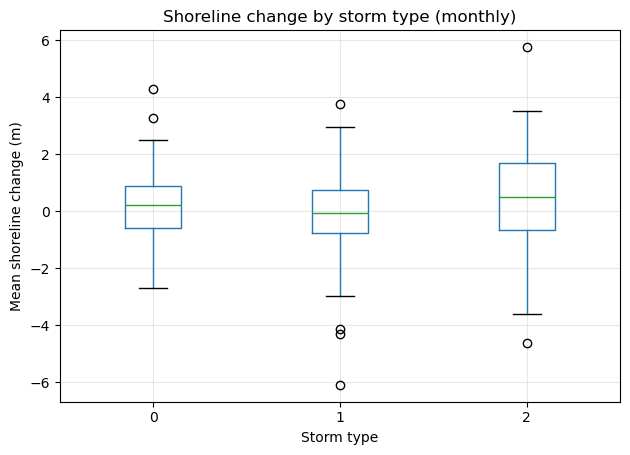

In [10]:
# Summary per storm type
type_summary = df.groupby("storm_type")[[
    "ecan_storm_hours","ecan_max_Hs","ecan_mean_Hs","ecan_mean_dir",
    "mean_shoreline_change"
]].agg(["count","mean","median","std"])

display(type_summary)

out_path = TABLE_DIR / "table_storm_type_summary.csv"
type_summary.to_csv(out_path)
print("Saved:", out_path)

# Boxplot shoreline change by storm type
plt.figure(figsize=(10,5))
df.boxplot(column="mean_shoreline_change", by="storm_type")
plt.title("Shoreline change by storm type (monthly)")
plt.suptitle("")
plt.xlabel("Storm type")
plt.ylabel("Mean shoreline change (m)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_shoreline_change_by_storm_type.png", dpi=200)
plt.show()
